In [1]:
import os
import sys
import glob

path = os.path.abspath("")
splitted = path.split(os.sep)
user_independent = os.path.join(
    splitted[0] + os.sep, splitted[1], splitted[2], splitted[3]
)
src_path = os.path.join(user_independent, "GitHub", "Photoswitching")
sys.path.append(src_path)

import src.distributions as dist
import src.fitting as fit

import pymc as pm
import arviz as az  
import numpy as np
import pandas as pd
import pytensor.tensor as pt
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

import warnings

def custom_warning_format(msg, category, filename, lineno, line=None):
    if line is None:
        import linecache

        line = linecache.getline(filename, lineno)
    return f"WARNING for line: {line} {msg} \n"


warnings.formatwarning = custom_warning_format

# Goal: constructing hierarchical bayesian model to infer distributions of parameters underlying the fingerprint model that leads to the observed data - maybe also mixture of number of fluorophores

Possible packages:
- PyMC
- NumPyro
- PyStan

In [1]:
from scipy.stats import expon, norm

parameter1 = expon.rvs(size=10000, scale=1)
parameter2 = norm.rvs(size=10000, loc=0, scale=1)

data = norm.rvs(size=10000, loc=parameter2, scale=parameter1)

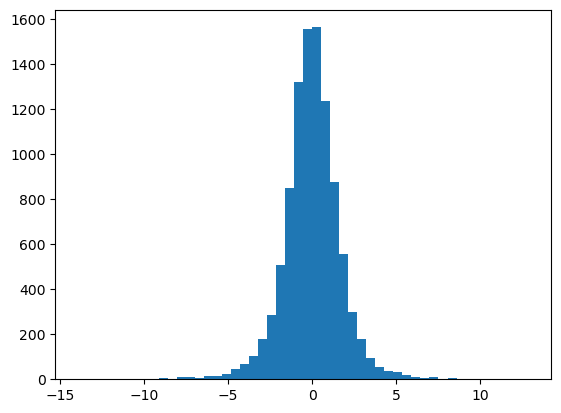

In [4]:
plt.hist(data, bins=50);

In [62]:
# Define the PyMC model
with pm.Model() as model:
    # Priors for unknown model parameters
    lambda_ = pm.Exponential('lambda_', 1.0, shape=10000)
    mu = pm.Normal('mu', 0, 1, shape=10000)
    
    # Likelihood (sampling distribution) of observations
    observed_data = pm.Normal('observed_data', mu=mu, sigma=lambda_, observed=data)
    
    # Inference
    trace = pm.sample(2000, tune=1000, return_inferencedata=True)

# # Plot the posterior distributions
# with model:
#     pm.plot_posterior(trace, var_names=['lambda_', 'mu'])
#     plt.show()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [lambda_, mu]


WARNING for line:                     warnings.warn('install "ipywidgets" for Jupyter support')
 install "ipywidgets" for Jupyter support

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 2849 seconds.
There were 5426 divergences after tuning. Increase `target_accept` or reparameterize.
Chain 1 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 2 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 3 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


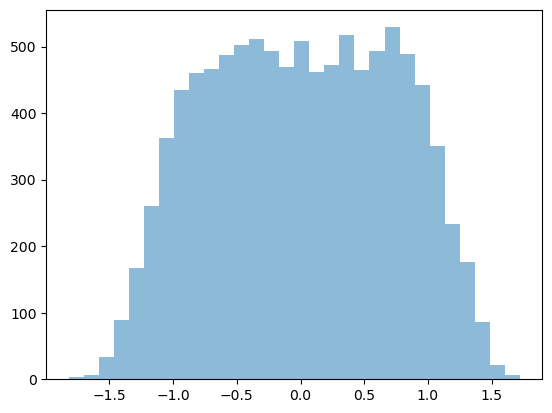

In [65]:
plt.hist(means, bins=30, alpha=0.5);

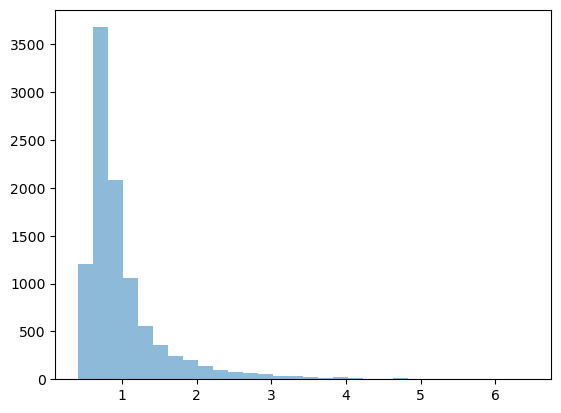

In [66]:
means = az.summary(trace, var_names=["lambda_"])['mean'].values
plt.hist(means, bins=30, alpha=0.5);

In [35]:
import pymc as pm
import numpy as np
import matplotlib.pyplot as plt

# Generate some synthetic data
np.random.seed(42)
true_p_mean = 5
true_p_std = 3
true_q_rate = 2.0

# Sample p and q
num_samples = 1000
p_samples = np.random.normal(loc=true_p_mean, scale=true_p_std, size=num_samples)
q_samples = np.random.exponential(scale=1/true_q_rate, size=num_samples)

# Assume target distribution D(p, q) is a joint distribution dependent on p and q
# For simplicity, let's say it is the sum of p and q with noise
observed_data = p_samples + q_samples + np.random.normal(0, 0.05, size=num_samples)

# PyMC model
with pm.Model() as model:
    # Priors for p and q
    p_mean = pm.Normal("p_mean", mu=0, sigma=1)
    p_std = pm.HalfNormal("p_std", sigma=1)
    q_rate = pm.HalfNormal("q_rate", sigma=1)

    # p and q distributions
    p = pm.Normal("p", mu=p_mean, sigma=p_std, shape=num_samples)
    q = pm.Exponential("q", lam=q_rate, shape=num_samples)

    # Target distribution D(p, q)
    target = pm.Normal("target", mu=p + q, sigma=0.05, observed=observed_data)

    # Inference
    trace = pm.sample(3000, tune=3000, return_inferencedata=True)


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [p_mean, p_std, q_rate, p, q]


WARNING for line:                     warnings.warn('install "ipywidgets" for Jupyter support')
 install "ipywidgets" for Jupyter support

Sampling 4 chains for 3_000 tune and 3_000 draw iterations (12_000 + 12_000 draws total) took 1428 seconds.
There were 823 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [ ]:
means = az.summary(trace, var_names=["p_mean", "p_std", "q_rate", "q"]).iloc[3:]['mean'].values
plt.hist(observed_data, bins=30);
plt.hist(means + means2, bins=30, alpha=0.5);

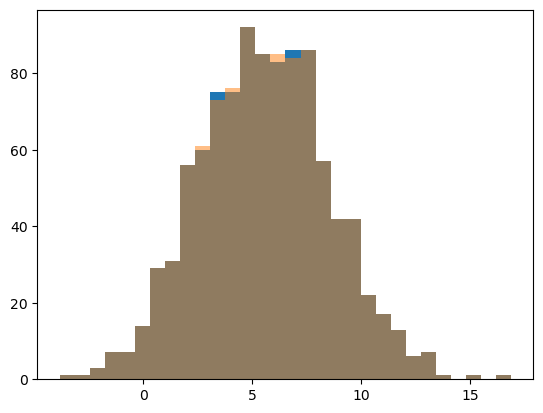

In [49]:
plt.hist(observed_data, bins=30);
plt.hist(means + means2, bins=30, alpha=0.5);

In [41]:
means2 = az.summary(trace, var_names=["p_mean", "p_std", "q_rate", "p"]).iloc[3:]['mean'].values

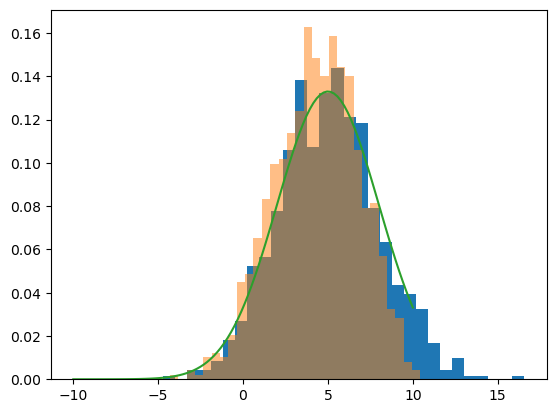

In [52]:
plt.hist(p_samples, density=True, bins=30,)
plt.hist(means2, bins=30, density=True, alpha=0.5)
plt.plot(np.linspace(-10, 10, 100), norm.pdf(np.linspace(-10, 10, 100), loc=true_p_mean, scale=true_p_std));

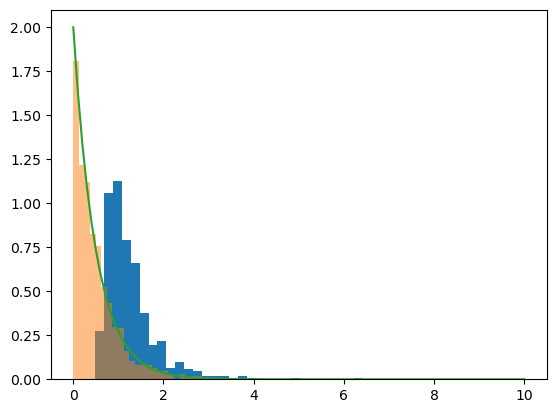

In [53]:
plt.hist(means, bins=30, density=True)
plt.hist(q_samples, density=True, bins=30, alpha=0.5)
plt.plot(np.linspace(0, 10, 100), expon.pdf(np.linspace(0, 10, 100), scale=1/true_q_rate));

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
p_mean,0.489,0.012,0.467,0.510,0.002,0.002,23.0,257.0,1.13
p_std,0.088,0.012,0.065,0.111,0.003,0.002,17.0,102.0,1.18
q_rate,1.932,0.073,1.807,2.080,0.009,0.006,70.0,950.0,1.04
q[0],0.142,0.083,0.001,0.282,0.001,0.001,3242.0,2148.0,1.00
q[1],0.078,0.061,0.000,0.190,0.001,0.001,3076.0,2416.0,1.00
...,...,...,...,...,...,...,...,...,...
q[995],0.130,0.079,0.000,0.266,0.001,0.001,3287.0,2199.0,1.00
q[996],0.229,0.099,0.032,0.409,0.002,0.002,1531.0,738.0,1.00
q[997],0.366,0.105,0.164,0.553,0.002,0.001,3366.0,1872.0,1.00
q[998],0.056,0.049,0.000,0.142,0.001,0.001,2774.0,2245.0,1.00


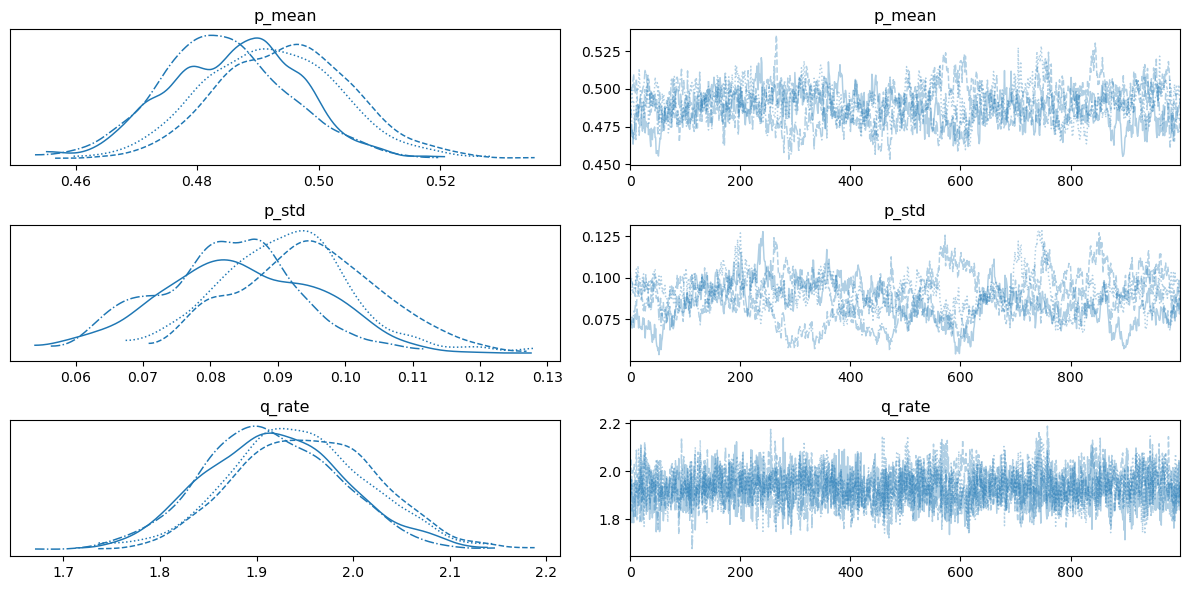

In [11]:
# Posterior analysis
import arviz as az
az.plot_trace(trace, var_names=["p_mean", "p_std", "q_rate"])
plt.tight_layout()

az.summary(trace, var_names=["p_mean", "p_std", "q_rate", "q"])

In [22]:
from itertools import product
def photoswitching_fingerprint_prepare(n, pis):
    """
    Get indices for valid lambda combinations for the photoswitching fingerprint model.
    Modifies the weights of the underlying exponential distributions by converting
    probabilities to 1, if their counterpart is not valid.

    Parameters
    ----------
    n : int
        Number of fluorophores.
    pis : 2-D array_like
        Weights of the underlying exponential distributions.

    Returns
    -------
    valid_combinations : 2-D array_like
        Valid combinations of lambdas.
    pis : 2-D array_like
        Modified weights of the underlying exponential distributions.
    """
    combinations = product([0, 1], repeat=n)
    valid_combinations = [
    comb for comb in combinations if all(
            not (comb[h] == 0 and comb[h-1] == 1) for h in range(1, n)
        )
    ]
    valid_combinations = np.array(valid_combinations, dtype=int)
    pis = pis[valid_combinations, np.arange(valid_combinations.shape[1])]
    for n, comb in enumerate(valid_combinations):
        ones = np.where(comb == 1)[0]
        if ones.size > 1:
            pis[n, ones[1:]] = 1

    return valid_combinations, pis

def hypoexponential_distribution_pdf(x, *args):
    """
    PDF of the hypoexponential distribution.

    Parameters
    ----------
    x : float, 1-D array_like
        Sample.
    args : float, 1-D array_like
        Parameters (lambdas) of the hypoexponential distribution.
    
    Returns
    -------
    pdf : float, 1-D array_like
        PDF of the hypoexponential distribution.
    """
    all_args = np.asarray(args)
    pdf = 0
    for arg in args:
        other_args = np.array([other for other in args if other != arg])
        pdf += pt.exp(-arg * x) *pt.prod(all_args) / pt.prod(- arg + other_args)

    return pdf


def photoswitching_fingerprint_pdf(x, lambdas, pis_orig):
    """
    PDF of the photoswitching fingerprint model.

    Parameters
    ----------
    x : float, 1-D array_like
        Sample.
    lambdas : float, 2-D array_like
        Rates of the underlying exponential distributions.
    pis_orig : float, 1-D array_like
        Weights of the underlying exponential distributions.
    
    Returns
    -------
    pdf : float, 1-D array_like
        Model output.
    """
    lambdas = np.asarray(lambdas)
    pis_orig = np.asarray(pis_orig)
    pis_orig = np.asarray([pis_orig, 1-pis_orig])
    n = lambdas.shape[1]
    pdf = 0
    for i in range(n):
        valid_combinations, pis = photoswitching_fingerprint_prepare(i+1, pis_orig)
        pdf_part = 0
        for j in range(i+2):
            pi_set = pt.prod(pis[j])
            pdf_part += pi_set * hypoexponential_distribution_pdf(
                x, 
                *lambdas[
                    valid_combinations[j], np.arange(valid_combinations[j].shape[0])
                ]
            )
        pdf += 1/n * pdf_part
    # truncation
    if pdf.size > 2:
        pdf = pdf / np.trapz(pdf, x)  # could also be normalized using cdf[-1] - cdf[0]
    
    return pdf

In [23]:
def photoswitching_fingerprint_logp(x, lambdas, pis_orig):
    pdf = photoswitching_fingerprint_pdf(x, lambdas, pis_orig)
    logp = pt.log(pdf)

    return logp

In [24]:
with pm.Model() as model:
    lam1 = pm.TruncatedNormal("lam1", mu=0.1, sigma=0.1, lower=1e-9)
    lam2 = pm.TruncatedNormal("lam2", mu=0.1, sigma=0.1, lower=1e-9)
    p = 0.5
    custom_dist = pm.DensityDist(
        name='custom_dist',
        logp=lambda x: photoswitching_fingerprint_logp(x, [[lam1, lam2]], [p]),
    )
    trace = pm.sample()


TypeError: Unsupported dtype for TensorType: object

In [ ]:

p = 0.6  # Mixing coefficient
mean_lam1, std_lam1 = 2.0, 0.3  # Parameters for lam1 normal distribution
mean_lam2, std_lam2 = 5.0, 0.5  # Parameters for lam2 normal distribution

# PyMC model
with pm.Model() as model:
    # Define priors for lam1 and lam2
    lam1 = pm.TruncatedNormal("lam1", mu=mean_lam1, sigma=std_lam1, lower=1e-9)
    lam2 = pm.Normal("lam2", mu=mean_lam2, sigma=std_lam2)
    
    # Mixture components
    exponential1 = pm.Exponential.dist(lam=lam1)
    exponential2 = pm.Exponential.dist(lam=lam2)
    
    # Mixture distribution
    mixture = pm.Mixture(
        "mixture",
        w=[p, 1 - p],  # Mixing weights
        comp_dists=[exponential1, exponential2],
        observed=None,  # This can be set to observed data if available
    )
    
    
    # Sampling
    trace = pm.sample(1000, return_inferencedata=True)

# Visualize the posterior distributions
az.plot_trace(trace)

## Sensitivity analysis
What parameters have the most impact?